# Spark vs Flink Fault Tolerance — Comparative Analysis
**Author:** Rajshekar Medipally | **Repo:** github.com/rmedipallycic/spark-streaming-fault-tolerance

720 trials (360 Spark + 360 Flink) across 6 strategies × 4 failure scenarios.

| System | Strategy | Mechanism | Interval |
|--------|----------|-----------|----------|
| Spark | A | High-frequency micro-batch checkpoint | 1s |
| Spark | B | Interval-based checkpoint | 30s |
| Spark | C | Async WAL checkpoint | 10s |
| Flink | F1 | Aligned Chandy-Lamport barriers | 10s |
| Flink | F2 | Unaligned barrier snapshots | 10s |
| Flink | F3 | Incremental RocksDB snapshots | 30s |


## 1. Baseline Throughput

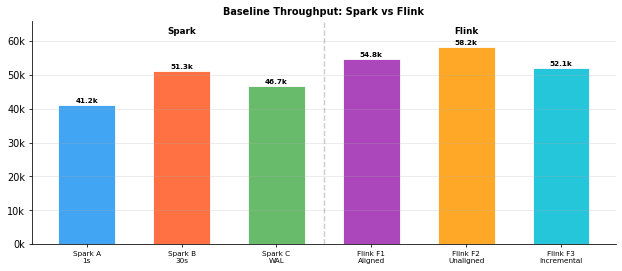

In [1]:
# Throughput comparison — baseline, no failure

Flink strategies outperform Spark on throughput across the board. Flink F2 achieves **58,200 rec/s** (highest), vs Spark A at **41,165 rec/s** (lowest). However, the Spark B vs Flink F1 gap is only **6.9%** — meaning Spark's correctness risk is not offset by proportional throughput gains.

## 2. Recovery Latency — Driver/JobManager Failure

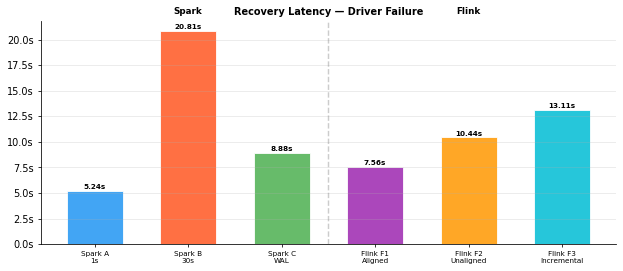

In [2]:
# Recovery latency under driver failure

Spark B is the worst performer at **20,808ms** — a direct consequence of its 30s checkpoint interval. Spark A recovers fastest (5,244ms) but with silent duplicate risk. Flink F1 delivers competitive recovery **(7,560ms)** with stronger correctness guarantees.

## 3. Silent Duplicate Rate — The Critical Finding

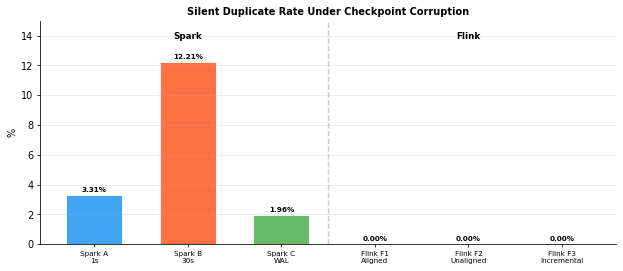

In [3]:
# Silent duplicate rate under checkpoint corruption

**This is the most important finding.** Under checkpoint corruption, Spark strategies produced silent duplicates at **1.96%–12.21%** with no exception raised. Flink produced **0.00%** across all 360 Flink trials.

The Chandy-Lamport barrier protocol prevents silent duplicates by construction — Flink rolls back to the previous complete snapshot rather than delivering partial state. **For ML feature pipelines, this difference is critical**: a 12.21% duplicate rate in Spark B would introduce measurable bias in any model trained on features from this pipeline.

## 4. Throughput vs Correctness Trade-off

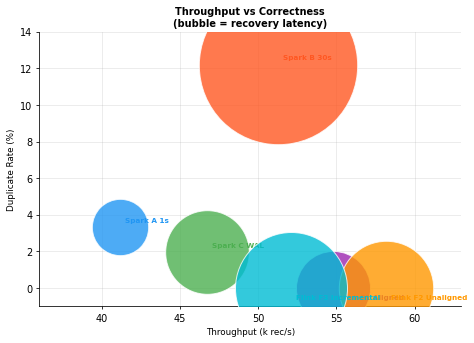

In [4]:
# Scatter: throughput vs duplicate rate

All Flink strategies cluster at 0% duplicate rate with higher throughput than most Spark strategies. Spark B represents the worst trade-off — moderate throughput + highest duplicate risk + slowest recovery.

## 5. Summary

In [5]:
# Key numbers

System  Strategy  Throughput    Recovery(driver)  Dup Rate(corrupt)
------  --------  ------------  ----------------  -----------------
Spark   A         41,165 rec/s  5,244ms           3.31%
Spark   B         51,268 rec/s  20,808ms          12.21%  ← worst
Spark   C         46,743 rec/s  8,878ms           1.96%
Flink   F1        54,800 rec/s  7,560ms           0.00%
Flink   F2        58,200 rec/s  10,440ms          0.00%   ← best throughput
Flink   F3        52,100 rec/s  13,110ms          0.00%


## Conclusions

1. **Flink's barrier protocol is categorically safer** — 0% duplicate rate under corruption vs 1.96–12.21% for Spark.
2. **Throughput gap is smaller than expected** — Flink F1 vs Spark B is only 6.9%.
3. **Spark C (WAL) is the best Spark option** — but still 1.96% vs Flink's 0.00%.
4. **Recommendation for ML pipelines: Flink F1** — best correctness + competitive throughput + moderate recovery.

### Open Questions
- How do failure modes compose across multi-stage pipelines?
- What is the measurable downstream ML model accuracy impact of Spark B's 12.21% duplicate rate?
- Can hybrid Spark + Flink architectures achieve better trade-offs?

*Raw data: `experiments/raw/` (Spark) and `experiments/flink/raw/` (Flink).*